In [27]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

import keras
from keras import layers
from keras import ops
from tensorflow.keras.models import Sequential
import keras_tuner as kt

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

TensorFlow 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [28]:
# load data 
d = np.load("processed_waveforms.npz")
 # ["X_euclidean"] or ["X_voltage"] 
X = d["X_euclidean"].astype(np.float32)  
# 0=photon, 1=neutron
y = d["y"].astype(np.int32)             

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Normalize to [0, 1]
minv = X_train.min(axis=0, keepdims=True)    
maxv = X_train.max(axis=0, keepdims=True)   
den  = np.maximum(maxv - minv, 1e-8)

X_train_n = (X_train - minv) / den
X_test_n  = (X_test  - minv) / den

Epoch 1/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0386 - val_loss: 0.0302
Epoch 2/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0295 - val_loss: 0.0293
Epoch 3/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0293 - val_loss: 0.0292
Epoch 4/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0289 - val_loss: 0.0287
Epoch 5/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0287 - val_loss: 0.0286
Epoch 6/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0285 - val_loss: 0.0283
Epoch 7/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0283 - val_loss: 0.0282
Epoch 8/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0281 - val_loss: 0.0281
Epoch 9/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0280 - val_loss: 0.0278
Epoch 10/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0278 - val_loss: 0.0278
Epoch 11/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0278 - val_loss: 0.0277
Epoch 12/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

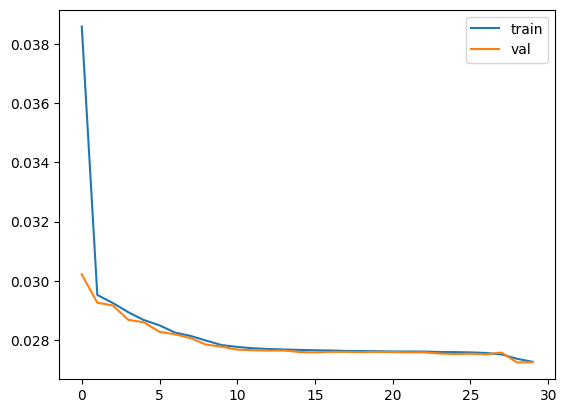

In [29]:
#Initial Basic Autoencoder 
class DenseAutoencoder(Model):
    def __init__(self, n_features=104, latent_dim=16):
        super().__init__()
        
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(n_features,)),
            layers.Dense(64, activation="relu"),
            layers.Dense(32, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(8, activation="relu"),
            layers.Dense(latent_dim, activation="relu"),
        ])
        self.decoder = tf.keras.Sequential([
            layers.Input(shape=(latent_dim,)),
            layers.Dense(16, activation="relu"),
            layers.Dense(32, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(n_features, activation="sigmoid"),  # output in [0,1]
        ])

    def call(self, x):
        return self.decoder(self.encoder(x))

#initialize and compile autoencoder 
ae = DenseAutoencoder(n_features=104, latent_dim=16)
ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mae")


history = ae.fit(
    X_train_n, X_train_n,
    validation_data=(X_test_n, X_test_n),
    epochs=30,
    batch_size=512,
    shuffle=True,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
    verbose=1
)

# Loss plot 
plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.show()

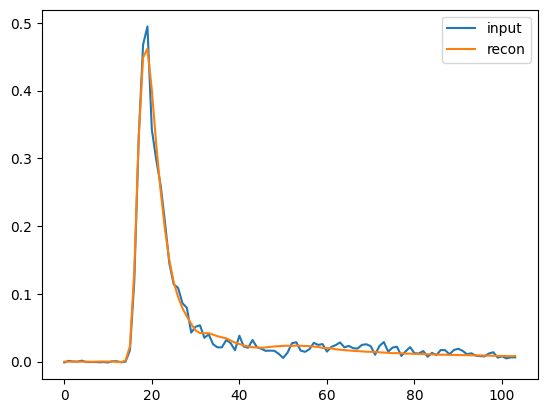

In [32]:
# Reconstruct and plot in original scale 
idx = 300
xhat_n = ae.predict(X_test_n[idx:idx+1], verbose=0)[0] 
# invert min-max to original scaling 
xhat   = xhat_n * den[0] + minv[0]                     
x      = X_test[idx]

plt.figure()
plt.plot(x, label="input")
plt.plot(xhat, label="recon")
plt.legend()
plt.show()

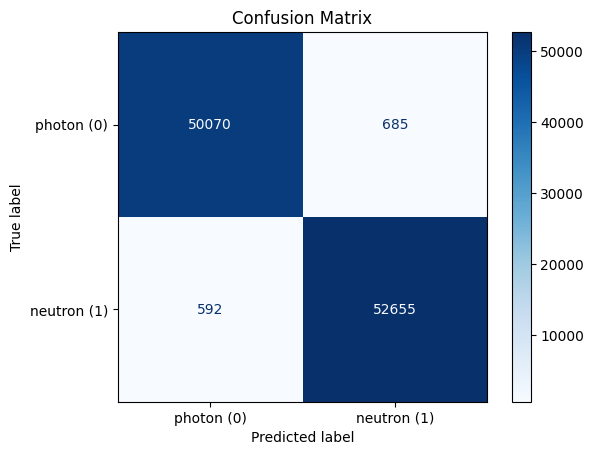

Photon misclassification rate (photon→neutron): 1.3496
Neutron misclassification rate (neutron→photon): 1.1118


In [34]:
#For demonstration I am using the Logistic regression classifier
#we could investigate better methods

#  Extract low-dim feature vectors from autoencoder
Z_train = ae.encoder(X_train_n).numpy()  
Z_test  = ae.encoder(X_test_n).numpy() 

#  Logistic regression classifier  
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight="balanced")
)

#Fit Logistic regression classifier 
clf.fit(Z_train, y_train)

#Predictions 
y_pred = clf.predict(Z_test)
p_neutron = clf.predict_proba(Z_test)[:, 1]


cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["photon (0)", "neutron (1)"]
)
disp.plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


tn, fp, fn, tp = cm.ravel()

 # true photon predicted neutron
photon_misclass_rate  = ( fp / (tn + fp) ) * 100
# true neutron predicted photon
neutron_misclass_rate = (fn / (tp + fn) ) * 100 

print(f"Photon misclassification rate (photon→neutron): {photon_misclass_rate:.4f}")
print(f"Neutron misclassification rate (neutron→photon): {neutron_misclass_rate:.4f}")